         x1        x2  etiqueta
0 -0.008864  0.113353         0
1  0.242456 -0.075897         0
2 -0.014196 -0.070382         0
3 -0.165579 -0.143002         0
4  0.202125  0.327485         0


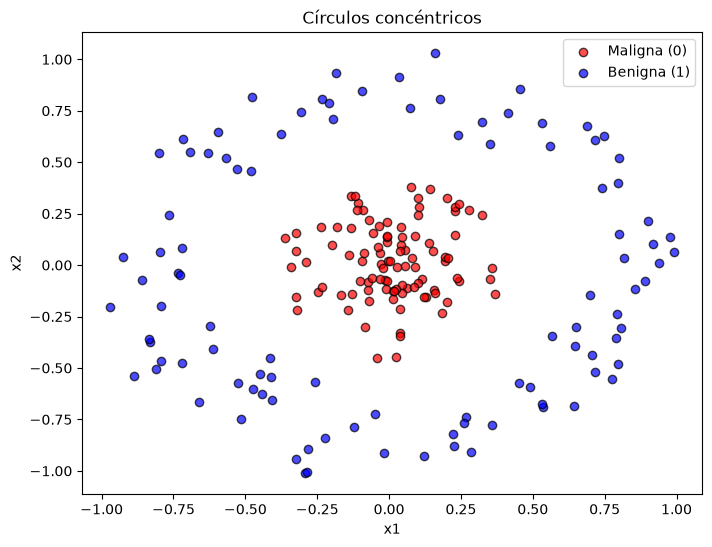

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
 
# 1. Configurar semilla para reproducibilidad
np.random.seed(42)
 
# 2. Definir parámetros
n_samples_per_class = 100  # 100 para malignas (0) y 100 para benignas (1)
n_total = n_samples_per_class * 2
 
# 3. Generar círculos concéntricos
# Clase 0: Círculo interno (Malignas)
theta_0 = np.random.uniform(0, 2 * np.pi, n_samples_per_class)
r_0 = np.random.uniform(0, 0.4, n_samples_per_class)  # Radio interno pequeño
x1_0 = r_0 * np.cos(theta_0)
x2_0 = r_0 * np.sin(theta_0)
y_0 = np.zeros(n_samples_per_class)
 
# Clase 1: Círculo externo (Benignas)
theta_1 = np.random.uniform(0, 2 * np.pi, n_samples_per_class)
r_1 = np.random.uniform(0.7, 1.0, n_samples_per_class)  # Radio externo grande
x1_1 = r_1 * np.cos(theta_1)
x2_1 = r_1 * np.sin(theta_1)
y_1 = np.ones(n_samples_per_class)
 
# 4. Combinar los datos
x1 = np.concatenate([x1_0, x1_1])
x2 = np.concatenate([x2_0, x2_1])
etiqueta = np.concatenate([y_0, y_1])
 
# 5. Agregar ruido al valor de x2
ruido = np.random.normal(0, 0.08, n_total)  # Ruido gaussiano con media 0 y desviación estándar 0.08
x2 = x2 + ruido
 
# 6. Crear un DataFrame de Pandas
df_celulas = pd.DataFrame({
    'x1': x1,
    'x2': x2,
    'etiqueta': etiqueta.astype(int)
})
 
# Mostrar las primeras 5 filas del dataset
print(df_celulas.head())
 
# 7. (Opcional) Visualizar los datos generados
plt.figure(figsize=(8, 6))
plt.scatter(df_celulas[df_celulas['etiqueta'] == 0]['x1'], 
            df_celulas[df_celulas['etiqueta'] == 0]['x2'], 
            color='red', label='Maligna (0)', alpha=0.7, edgecolors='k')
plt.scatter(df_celulas[df_celulas['etiqueta'] == 1]['x1'], 
            df_celulas[df_celulas['etiqueta'] == 1]['x2'], 
            color='blue', label='Benigna (1)', alpha=0.7, edgecolors='k')
plt.title('Círculos concéntricos')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.show()

Iteration 1, loss = 0.82896952
Validation score: 0.500000
Iteration 2, loss = 0.75434818
Validation score: 0.500000
Iteration 3, loss = 0.70506507
Validation score: 0.687500
Iteration 4, loss = 0.68414201
Validation score: 0.718750
Iteration 5, loss = 0.66284604
Validation score: 0.656250
Iteration 6, loss = 0.64545367
Validation score: 0.656250
Iteration 7, loss = 0.63055427
Validation score: 0.593750
Iteration 8, loss = 0.61773308
Validation score: 0.562500
Iteration 9, loss = 0.60622054
Validation score: 0.562500
Iteration 10, loss = 0.59488020
Validation score: 0.656250
Iteration 11, loss = 0.58292059
Validation score: 0.687500
Iteration 12, loss = 0.57002193
Validation score: 0.718750
Iteration 13, loss = 0.55670090
Validation score: 0.750000
Iteration 14, loss = 0.54293929
Validation score: 0.750000
Iteration 15, loss = 0.52863120
Validation score: 0.812500
Iteration 16, loss = 0.51589302
Validation score: 0.812500
Iteration 17, loss = 0.50627443
Validation score: 0.875000
Iterat

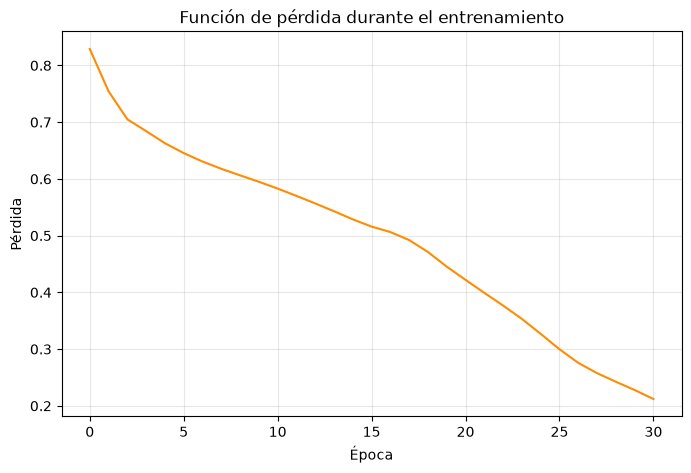

In [9]:
# 8. Preparar datos de entrenamiento y prueba
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, log_loss, classification_report
import joblib

X = df_celulas[['x1', 'x2']]
y = df_celulas['etiqueta']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Estandarizar usando únicamente los datos de entrenamiento
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 9. Crear y entrenar la red neuronal MLP
# Con early_stopping, el lote completo corresponde al subconjunto de entrenamiento
validation_fraction = 0.2
batch_size_completo = int(len(X_train_scaled) * (1 - validation_fraction))

modelo_mlp = MLPClassifier(
    hidden_layer_sizes=(16, 8, 4),
    learning_rate_init=0.03,
    max_iter=100,
    batch_size=batch_size_completo,
    early_stopping=True,
    validation_fraction=validation_fraction,
    tol=0.001,
    n_iter_no_change=10,
    random_state=42,
    verbose=True
)

modelo_mlp.fit(X_train_scaled, y_train)

# Darle persistencia al modelo entrenado
joblib.dump(modelo_mlp, 'modelo_mlp_circulos.joblib')
joblib.dump(scaler, 'scaler_mlp_circulos.joblib')
print('Modelo y escalador guardados correctamente.')

# 10. Evaluar el modelo y mostrar la función de pérdida logarítmica
probabilidades = modelo_mlp.predict_proba(X_test_scaled)
predicciones = modelo_mlp.predict(X_test_scaled)

print(f'Epocas ejecutadas: {modelo_mlp.n_iter_}')
print(f'Pérdida final de entrenamiento: {modelo_mlp.loss_curve_[-1]:.4f}')
print(f'Pérdida logarítmica en prueba: {log_loss(y_test, probabilidades):.4f}')
print(f'Exactitud en prueba: {accuracy_score(y_test, predicciones):.4f}')
print(classification_report(y_test, predicciones, target_names=['Maligna (0)', 'Benigna (1)']))

plt.figure(figsize=(8, 5))
plt.plot(modelo_mlp.loss_curve_, color='darkorange')
plt.title('Función de pérdida durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.grid(alpha=0.3)
plt.show()

In [10]:
from sklearn.metrics import classification_report

# Generar predicciones con el modelo entrenado
predicciones_mlp = modelo_mlp.predict(X_test_scaled)

# Mostrar el reporte de clasificación
reporte_clasificacion = classification_report(
    y_test,
    predicciones_mlp,
    target_names=['Maligna (0)', 'Benigna (1)']
)

print('Reporte de clasificación del modelo MLP:')
print(reporte_clasificacion)

Reporte de clasificación del modelo MLP:
              precision    recall  f1-score   support

 Maligna (0)       0.94      0.85      0.89        20
 Benigna (1)       0.86      0.95      0.90        20

    accuracy                           0.90        40
   macro avg       0.90      0.90      0.90        40
weighted avg       0.90      0.90      0.90        40



In [22]:
# Predicción para una nueva célula
nueva_celula = pd.DataFrame({'x1': [0.1], 'x2': [0.1]})
nueva_celula_escalada = scaler.transform(nueva_celula)

prediccion = modelo_mlp.predict(nueva_celula_escalada)[0]
probabilidades = modelo_mlp.predict_proba(nueva_celula_escalada)[0]

# Codificación usada durante el entrenamiento: 0 = Maligna, 1 = Benigna
nombre_clase = {0: 'Maligna', 1: 'Benigna'}

print(f'Predicción para x1=0.1 y x2=0.1: {prediccion} ({nombre_clase[prediccion]})')
print(f'Probabilidad de ser Maligna (clase 0): {probabilidades[0]:.2%}')
print(f'Probabilidad de ser Benigna (clase 1): {probabilidades[1]:.2%}')

Predicción para x1=0.1 y x2=0.1: 0 (Maligna)
Probabilidad de ser Maligna (clase 0): 59.04%
Probabilidad de ser Benigna (clase 1): 40.96%
